**Data Collection / Acquisition**

Gather the dataset from available sources (e.g., CSV, database, API).

**Data Cleaning / Preprocessing**

Handle missing data, drop unnecessary columns (e.g., ID column), fix incorrect or inconsistent values (e.g., '-' in "Levy", '04-May', '02-Mar', '>5' "Doors", ect).
Convert data types as necessary (e.g., categorical to numeric).
Normalize or scale data if needed for certain algorithms.

**Exploratory Data Analysis (EDA)**

**1.Univariate Analysis (Numeric and Categorical features):** This is where you perform analysis on individual variables to understand their distribution, detect outliers, and check for trends.

**Numeric Features:** Plot histograms or boxplots to visualize distributions (e.g., Price, Mileage).
**Categorical Features:** Use bar plots to examine the frequency of categories (e.g., Manufacturer, Fuel type).

**2.Bivariate Analysis:** In this step, you analyze relationships between two variables at a time.

**Numeric vs. Numeric:** Use scatterplots or correlation matrices to explore the relationship (e.g., Price vs. Mileage).
**Numeric vs. Categorical:** Use boxplots or violin plots to compare numeric features across categories (e.g., Price by Fuel type).
**Categorical vs. Categorical:** Use cross-tabulations or heatmaps to explore relationships between two categorical features (e.g., Fuel type vs. Gear box type).

**Feature Engineering**

Create new features that could be useful for modeling based on the insights from EDA (e.g., transforming Mileage into categories like low, medium, high).

**Modeling**

Select appropriate models (e.g., linear regression, decision trees) and train the model using the cleaned and processed data.

**Model Evaluation**

Evaluate model performance using metrics like accuracy, RMSE, or others based on the type of model used.

**Model Tuning**

Fine-tune model hyperparameters to improve performance.

**Deployment & Reporting**

Deploy the model for real-world use and create reports or visualizations to communicate findings.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv


# Data Collection


In [2]:
data = pd.read_csv(r'/kaggle/input/car-price-prediction-challenge/car_price_prediction.csv')
data

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


# Data Cleaning & Preprocessing

In [3]:
data.head(3)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2


In [4]:
data.tail(3)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4
19236,45813273,470,753,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923 km,4.0,Automatic,Front,04-May,Left wheel,White,12


In [5]:
print("The number of rows  is :",data.shape[0])
print("The number of columns is :",data.shape[1])

The number of rows  is : 19237
The number of columns is : 18


In [6]:
data.dtypes

ID                    int64
Price                 int64
Levy                 object
Manufacturer         object
Model                object
Prod. year            int64
Category             object
Leather interior     object
Fuel type            object
Engine volume        object
Mileage              object
Cylinders           float64
Gear box type        object
Drive wheels         object
Doors                object
Wheel                object
Color                object
Airbags               int64
dtype: object

In [7]:
#Check statistics of Dataset #Only for numeric features
data.describe() 

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

# Car Variety 🚗🚙

The dataset includes 1,590 unique car models, showing a diverse range of vehicles.

 
# Price Range 💰

Median Price: €13,172 (50% of cars cost less than this).
Mean Price: €18,556, which is higher than the median, suggesting right-skewed data (some very expensive cars are pulling the average up).

Max Price: €26.3 million—this is an extreme outlier, likely a luxury or rare car.

Min Price: €1—probably an entry error or a very old/damaged car.

Possible Insights & Actions:

Data Cleaning Needed: The €1 price and 26.3M price suggest possible errors or extreme outliers.
Market Trend: Most cars are from 2010+, meaning the dataset leans toward newer models.
Luxury vs. Economy: The high max values for price, cylinders, and airbags indicate that the dataset includes both budget and premium cars.

In [9]:
print(data.columns)

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='object')


In [10]:
# Checking for Missing values
data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [11]:
data.isnull().sum().sum()

0

In [12]:
# Check the number of unique values of each column
data.nunique()

ID                  18924
Price                2315
Levy                  559
Manufacturer           65
Model                1590
Prod. year             54
Category               11
Leather interior        2
Fuel type               7
Engine volume         107
Mileage              7687
Cylinders              13
Gear box type           4
Drive wheels            3
Doors                   3
Wheel                   2
Color                  16
Airbags                17
dtype: int64

In [13]:
# Check for duplication
data.duplicated().sum()

313

In [14]:
# Remove all duplications
data.drop_duplicates(inplace = True)
data.shape[0]

18924

**The ID column do not carry any meaningful information to predict the target variable (car price), it does not help the model understand patterns in the data. So I will drop it.**

In [15]:
data.drop(columns=['ID'], axis=1, inplace=True)
data.head(7)


,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12


In [16]:
(data['Levy'] == '-').sum()

5709

**Feature transformation**

5,819 rows in the **'Levy'** column contain the value '-'.

**Mileage:** is stored as a Object (e.g., "100,000 km"), so we need to convert it to an integer.

**Engine volume:** If it includes letters like "2.0 Turbo", we'll need to extract the numeric part.

**Doors:** is categorical and has inconsistent values (e.g., "04-May", '02-Mar', '>5'), we have to clean it up.


In [17]:
# Convert 'Cylinders' column from float64 to int64

data["Cylinders"] = data["Cylinders"].astype('int64')
################################################################################################

#There are non-numeric values (like '-') in the 'Levy' column that cannot be directly converted to integers. 
#To handle this, I'll transform the column before converting it.

# Step 1: Replace '-' with NaN
data['Levy'] = pd.to_numeric(data['Levy'], errors='coerce')

# Step 2: Convert to int64 
data['Levy'] = data['Levy'].fillna(0).astype('int64')  # Replace NaN with 0 value
###############################################################################################

# 'Engine volume' column contains values like '2.2 Turbo', where "2.2" is a float and "Turbo" is a string.
#I need first to extract the numeric part then convert it into int64

data["Engine volume"].unique() 

#  Step 1: Replace 'Turbo' with  empty string (or NaN)
data['Engine volume'] = pd.to_numeric(data['Engine volume'].replace(r'\s*Turbo', '', regex=True))

#  Step 2: Convert the column to numeric, errors='coerce' will handle any other non-numeric values and convert them to NaN
data['Engine volume'] = pd.to_numeric(data['Engine volume'], errors='coerce')

#  Step 3: fill NaN with 0 
data['Engine volume'] = data['Engine volume'].fillna(0)

# Convert to float64
data['Engine volume'] = data['Engine volume'].astype('float64')
###############################################################################################


# Step 1: Replace 'Km' with ''
data['Mileage'] = pd.to_numeric(data['Mileage'].replace(r'\s*km', '', regex=True))

# Step 2:Convert Mileage to int64 
data["Mileage"] = data["Mileage"].astype('int64')
###################################################################

# Replace Doors with numeric values

data['Doors'].replace({'04-May': 4, '02-Mar': 2, '>5': 5}, inplace=True)


print(data["Cylinders"])
print()
print(data['Levy'])
print(data['Engine volume'])
print(data['Mileage'])
print(data['Doors'])

0        6
1        6
2        4
3        4
4        4
        ..
19232    4
19233    4
19234    4
19235    4
19236    4
Name: Cylinders, Length: 18924, dtype: int64

0        1399
1        1018
2           0
3         862
4         446
         ... 
19232       0
19233     831
19234     836
19235    1288
19236     753
Name: Levy, Length: 18924, dtype: int64
0        3.5
1        3.0
2        1.3
3        2.5
4        1.3
        ... 
19232    2.0
19233    2.4
19234    2.0
19235    2.0
19236    2.4
Name: Engine volume, Length: 18924, dtype: float64
0        186005
1        192000
2        200000
3        168966
4         91901
          ...  
19232    300000
19233    161600
19234    116365
19235     51258
19236    186923
Name: Mileage, Length: 18924, dtype: int64
0        4
1        4
2        4
3        4
4        4
        ..
19232    2
19233    4
19234    4
19235    4
19236    4
Name: Doors, Length: 18924, dtype: int64


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  int64  
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  object 
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  int64  
 10  Cylinders         18924 non-null  int64  
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  int64  
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

  """
    We will detects outliers using the IQR method, optionally we will replace them with the median, and visualizes them using box plots.

    Parameters:
    - data_check: DataFrame containing numerical data.

    - replace: If True, replaces outliers with the median value.

    Returns:
    - A modified DataFrame with outliers replaced if `replace=True`, otherwise the original.
    """


Replacing outliers in column: Price


Outliers in 'Price' before replacement:
14    59464
36    51746
47    55390
56    87112
73    53154
Name: Price, dtype: int64


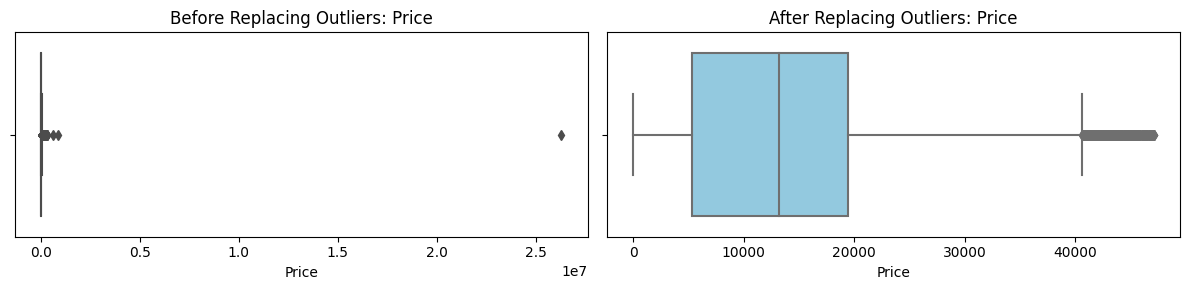

Outliers replaced in Price:
14       13172
36       13172
47       13172
56       13172
73       13172
         ...  
19144    13172
19161    13172
19180    13172
19188    13172
19211    13172
Name: Price, Length: 1055, dtype: int64

Replacing outliers in column: Levy


Outliers in 'Levy' before replacement:
18      2386
26      2455
78      2455
115    11714
132     2866
Name: Levy, dtype: int64


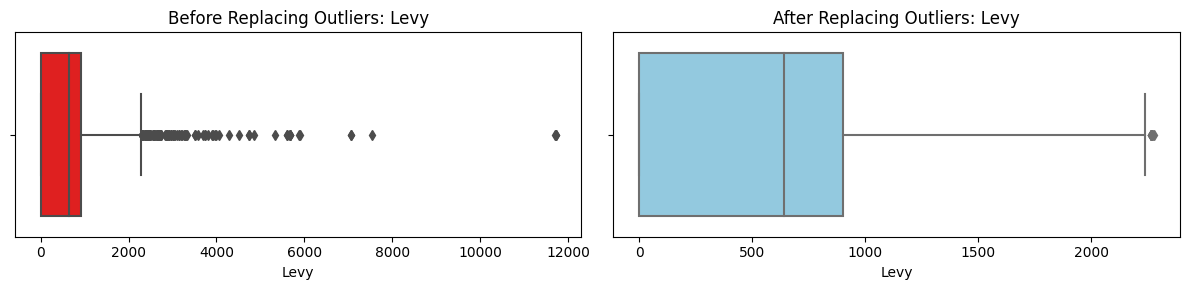

Outliers replaced in Levy:
18       642
26       642
78       642
115      642
132      642
        ... 
18854    642
18957    642
18963    642
18984    642
19048    642
Name: Levy, Length: 160, dtype: int64

Replacing outliers in column: Engine volume


Outliers in 'Engine volume' before replacement:
11    4.0
26    4.7
32    4.4
44    3.6
45    4.0
Name: Engine volume, dtype: float64


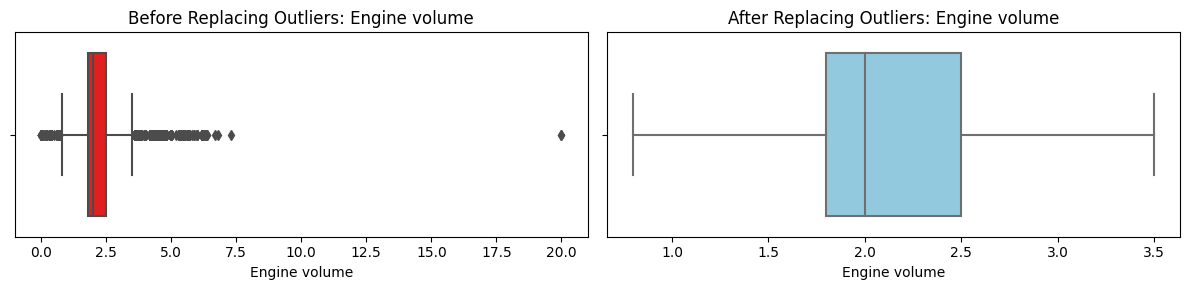

Outliers replaced in Engine volume:
11       2.0
26       2.0
32       2.0
44       2.0
45       2.0
        ... 
19038    2.0
19045    2.0
19048    2.0
19058    2.0
19186    2.0
Name: Engine volume, Length: 1358, dtype: float64

Replacing outliers in column: Mileage


Outliers in 'Mileage' before replacement:
8     398069
29    420550
39    382746
65    719847
90    433811
Name: Mileage, dtype: int64


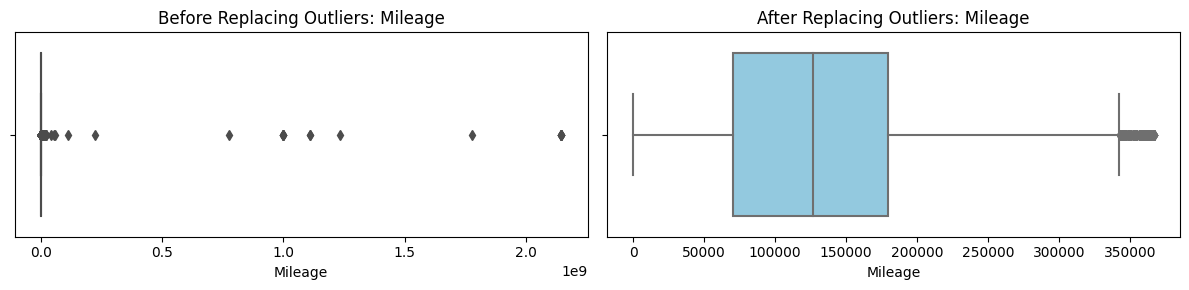

Outliers replaced in Mileage:
8        126400
29       126400
39       126400
65       126400
90       126400
          ...  
19163    126400
19167    126400
19194    126400
19199    126400
19222    126400
Name: Mileage, Length: 635, dtype: int64

Replacing outliers in column: Cylinders


Outliers in 'Cylinders' before replacement:
0     6
1     6
9     6
10    6
11    8
Name: Cylinders, dtype: int64


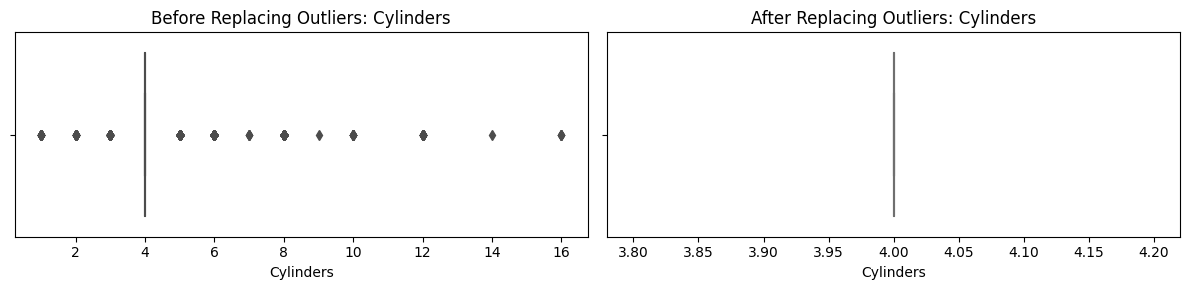

Outliers replaced in Cylinders:
0        4
1        4
9        4
10       4
11       4
        ..
19221    4
19226    4
19227    4
19228    4
19231    4
Name: Cylinders, Length: 4765, dtype: int64

Replacing outliers in column: Airbags


Outliers in 'Airbags' before replacement:
Series([], Name: Airbags, dtype: int64)


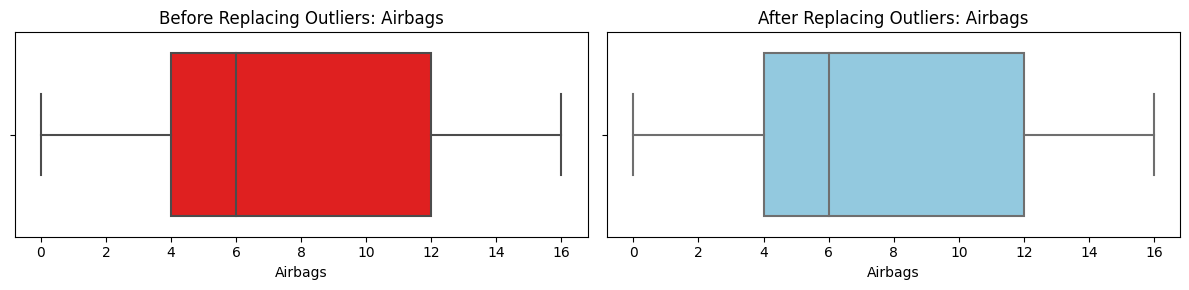

Outliers replaced in Airbags:
Series([], Name: Airbags, dtype: int64)

Replacing outliers in column: Doors


Outliers in 'Doors' before replacement:
11    2
23    2
55    2
75    2
95    2
Name: Doors, dtype: int64


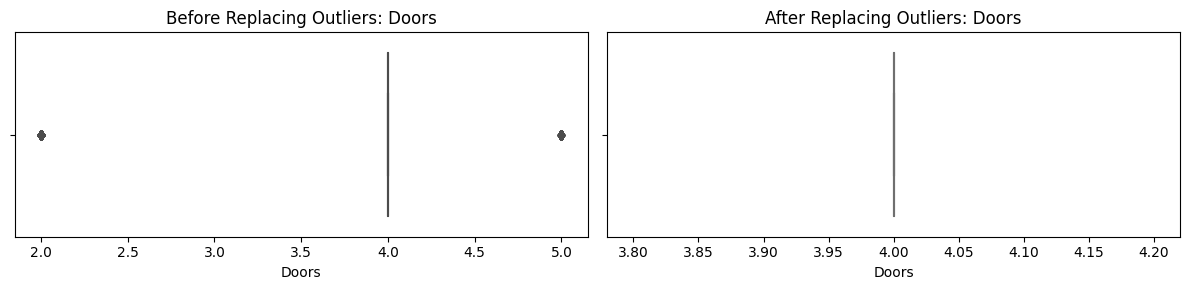

Outliers replaced in Doors:
11       4
23       4
55       4
75       4
95       4
        ..
19115    4
19118    4
19167    4
19169    4
19232    4
Name: Doors, Length: 892, dtype: int64

Final DataFrame after outlier replacement:
   Price  Levy  Engine volume  Mileage  Cylinders  Airbags  Doors
0  13328  1399            3.5   186005          4       12      4
1  16621  1018            3.0   192000          4        8      4
2   8467     0            1.3   200000          4        2      4
3   3607   862            2.5   168966          4        0      4
4  11726   446            1.3    91901          4        4      4


In [19]:
# Selecting relevant columns for outlier detection
data_check = data[['Price','Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags','Doors']].copy()

# Function to replace outliers in a column with the median
def replace_outliers_with_median(dataframe, col):
    if col not in dataframe.columns:
        raise KeyError(f"Column '{col}' not found in the DataFrame.")

    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)

# Print the original outlier values before replacing them
    print(f"\nOutliers in '{col}' before replacement:")
    print(dataframe.loc[outliers, col].head(5))  # Display first 5 outliers

 # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))  # 1 row, 2 columns
    
# Plot before replacement
    sns.boxplot(x=dataframe[col], ax=axes[0], color='red')
    axes[0].set_title(f"Before Replacing Outliers: {col}")
    

# Replace outliers with the median
    median_value = dataframe[col].median()
    dataframe.loc[outliers, col] = median_value

 # Plot after replacement
    sns.boxplot(x=dataframe[col], ax=axes[1], color='skyblue')
    axes[1].set_title(f"After Replacing Outliers: {col}")

    plt.tight_layout()
    plt.show() 
    
    return outliers  # Return mask of outliers

# Apply function to each column
for col in ['Price','Levy', 'Engine volume', 'Mileage', 'Cylinders', 'Airbags','Doors']:
    print(f"\n\033[1mReplacing outliers in column: {col}\033[0m")  # Bold text
    print() 
    outliers = replace_outliers_with_median(data_check, col)

    print(f"Outliers replaced in {col}:")
   
    print(data_check.loc[outliers, col])  # Show replaced values

# ✅ Display the modified DataFrame
print("\nFinal DataFrame after outlier replacement:")
print(data_check.head())

# Visualisation & Analysis

In [20]:
for i in data.columns: 
    print(i, ":", data[i].nunique())  # Number of unique 

Price : 2315
Levy : 559
Manufacturer : 65
Model : 1590
Prod. year : 54
Category : 11
Leather interior : 2
Fuel type : 7
Engine volume : 65
Mileage : 7687
Cylinders : 13
Gear box type : 4
Drive wheels : 3
Doors : 3
Wheel : 2
Color : 16
Airbags : 17


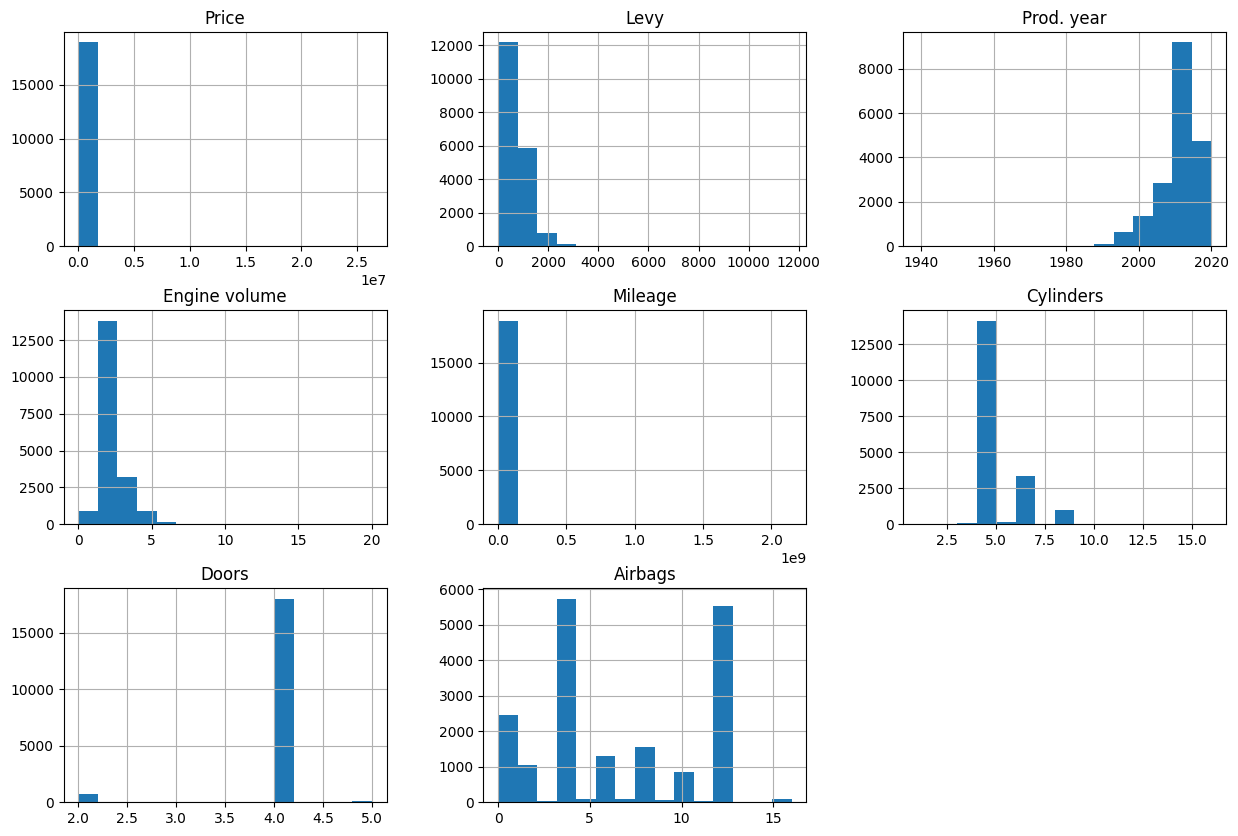

In [21]:
data.hist(bins= 15, figsize =(15,10))
plt.show() 


In [22]:
 #Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Compute correlation
correlation_matrix = numeric_data.corr()

# Display result
print(correlation_matrix)

                  Price      Levy  Prod. year  Engine volume   Mileage  \
Price          1.000000 -0.003558    0.012689       0.008888 -0.001763   
Levy          -0.003558  1.000000    0.362827       0.378117 -0.021203   
Prod. year     0.012689  0.362827    1.000000      -0.032427 -0.064058   
Engine volume  0.008888  0.378117   -0.032427       1.000000 -0.006292   
Mileage       -0.001763 -0.021203   -0.064058      -0.006292  1.000000   
Cylinders      0.007435  0.251632   -0.099443       0.777228 -0.001720   
Doors         -0.033387  0.096430    0.195710      -0.017697 -0.006287   
Airbags       -0.012709  0.125015    0.235160       0.221991 -0.009174   

               Cylinders     Doors   Airbags  
Price           0.007435 -0.033387 -0.012709  
Levy            0.251632  0.096430  0.125015  
Prod. year     -0.099443  0.195710  0.235160  
Engine volume   0.777228 -0.017697  0.221991  
Mileage        -0.001720 -0.006287 -0.009174  
Cylinders       1.000000 -0.036033  0.174112  
Door

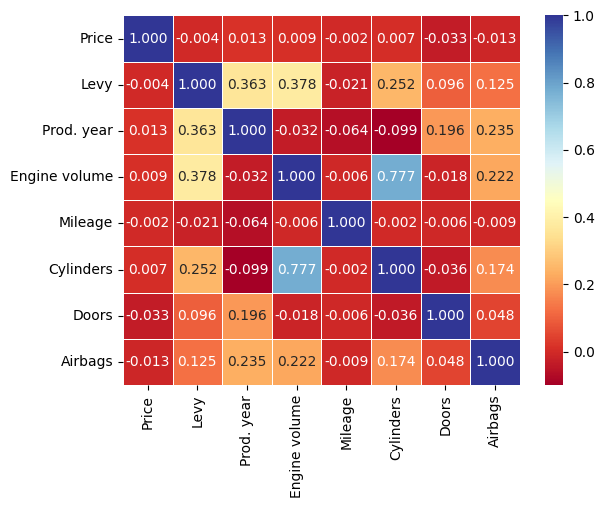

In [23]:
sns.heatmap(correlation_matrix , annot =True ,linewidths= 0.5, cmap= 'RdYlBu', fmt= '.3f' )
plt.show()

In [24]:
data["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFA ROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ',
       'CITROEN', 'LAND ROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR',
       'ISUZU', 'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC',
       'PEUGEOT', 'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION',
       'UAZ', 'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTON MARTIN', 'GREATWALL'], dtype=object)

In [25]:
# Find the top 10 manufacturers by count
top10_manufacturers = data["Manufacturer"].value_counts().sort_values(ascending = False)[:10]
top10_manufacturers

Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
BMW              1036
HONDA             960
LEXUS             927
NISSAN            645
VOLKSWAGEN        571
Name: count, dtype: int64

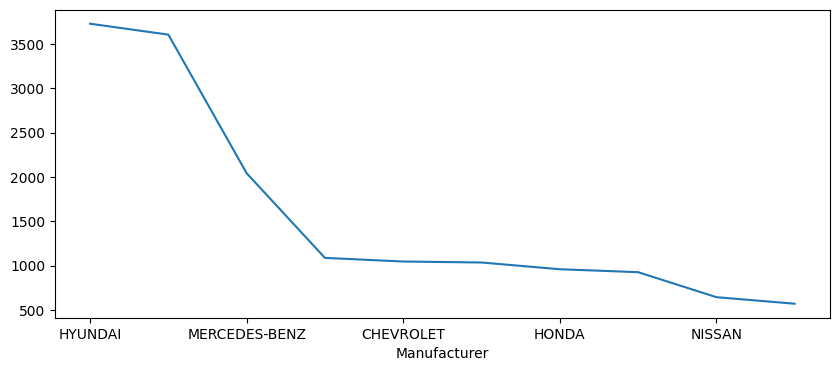

In [26]:
top10_manufacturers.plot(figsize= (10,4))
plt.show()

In [27]:
top10_price = data.nlargest(10, "Price")  # Get top 10 most expensive cars
top10_price 

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
16983,26307500,0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999,4,Manual,Front,2,Left wheel,Blue,0
8541,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531,8,Tiptronic,4x4,4,Left wheel,Black,0
1225,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3,0,8,Tiptronic,4x4,4,Left wheel,Black,12
5008,308906,1694,PORSCHE,911,2016,Coupe,Yes,Petrol,4.0,8690,6,Automatic,Rear,2,Left wheel,Black,12
9367,297930,0,MERCEDES-BENZ,AMG GT S,2015,Coupe,Yes,Petrol,4.0,20000,8,Tiptronic,Rear,2,Left wheel,White,16
14839,297930,0,LAND ROVER,Range Rover Vogue,2019,Jeep,Yes,Diesel,3.0,4500,8,Tiptronic,4x4,4,Left wheel,Black,12
7749,288521,2269,BMW,M5 Машина в максимально,2018,Sedan,Yes,Petrol,4.4,13500,8,Tiptronic,4x4,4,Left wheel,Black,0
10759,260296,0,LEXUS,LX 570,2018,Jeep,Yes,Petrol,5.7,17700,8,Tiptronic,4x4,4,Left wheel,Black,10
5840,254024,1292,MERCEDES-BENZ,GLE 400 A M G,2016,Jeep,Yes,Petrol,3.0,73000,6,Tiptronic,4x4,4,Left wheel,Black,12
15283,250574,1481,MERCEDES-BENZ,GLE 400,2017,Jeep,Yes,Petrol,3.0,81600,6,Tiptronic,4x4,4,Left wheel,Black,12


In [28]:
top10_manufacturers = data["Manufacturer"].value_counts().head(10).index

# Filter data to include only these manufacturers
filtered_data = data[data["Manufacturer"].isin(top10_manufacturers)]

# Calculate mean price for each manufacturer
mean_prices = filtered_data.groupby("Manufacturer")["Price"].mean().sort_values(ascending= False)

print("Mean price of cars for the top 10 manufacturers:\n", mean_prices)

Mean price of cars for the top 10 manufacturers:
 Manufacturer
HYUNDAI          22306.000805
BMW              20609.468147
LEXUS            20052.594391
MERCEDES-BENZ    18590.331375
FORD             15411.850184
CHEVROLET        14894.873926
TOYOTA           14302.447865
HONDA            14162.073958
VOLKSWAGEN       11471.774081
NISSAN            9835.840310
Name: Price, dtype: float64


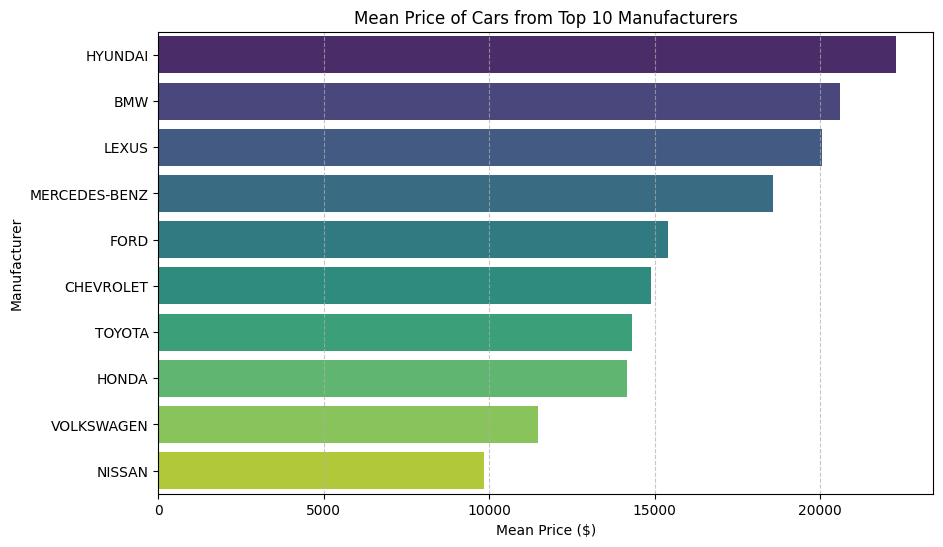

In [29]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_prices.values, y=mean_prices.index, palette="viridis")

# Labels and title
plt.xlabel("Mean Price ($)")
plt.ylabel("Manufacturer")
plt.title("Mean Price of Cars from Top 10 Manufacturers")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Show plot
plt.show()

In [30]:
# Ensure column names are clean
data.columns = data.columns.str.strip()

# Check if 'Prod. year' exists in the DataFrame before proceeding
if 'Prod. year' in data.columns:
    # Convert to numeric, handle errors, and drop missing values
    data['Prod. year'] = pd.to_numeric(data['Prod. year'], errors='coerce')
    data = data.dropna(subset=['Prod. year', 'Price'])

    # Ensure 'Prod. year' is an integer
    data['Prod. year'] = data['Prod. year'].astype(int)

    # Check min and max year before processing
    print("Min year:", data['Prod. year'].min(), "Max year:", data['Prod. year'].max())

    # Group by production year and calculate the average price
    avg_price_by_year = data.groupby('Prod. year', as_index=False)['Price'].mean()

    # Sort by production year
    avg_price_by_year = avg_price_by_year.sort_values('Prod. year')

    # Print first 15 rows to check if all years exist
    print(avg_price_by_year.head(15))

    # Create a line plot
    fig = px.line(avg_price_by_year, x='Prod. year', y='Price', 
                  markers=True, 
                  title='Average Car Price by Year',
                  labels={'Prod. year': 'Production Year', 'Price': 'Average Price (€)'})

    # Increase figure size
    fig.update_layout(width=1300, height=700)

    # Add hover functionality
    fig.update_traces(hoverinfo="x+y", mode="lines+markers")

    # Show plot
    fig.show()
else:
    print("❌ Error: Column 'Prod. year' not found in the dataset!")
    print("Available columns:", data.columns)


Min year: 1939 Max year: 2020
    Prod. year          Price
0         1939     171.333333
1         1943  119172.000000
2         1947     150.000000
3         1953   17735.250000
4         1957    7527.000000
5         1964    6585.500000
6         1965   65074.000000
7         1968    2200.000000
8         1973   15681.000000
9         1974    2437.000000
10        1976     400.000000
11        1977   10340.500000
12        1978    1400.000000
13        1980    1925.000000
14        1981    2800.000000


In [31]:
# Find the year with the smallest and largest average prices
min_price_index = avg_price_by_year['Price'].idxmin()
max_price_index = avg_price_by_year['Price'].idxmax()

min_price_row = avg_price_by_year.loc[min_price_index, ['Prod. year', 'Price']]
max_price_row = avg_price_by_year.loc[max_price_index, ['Prod. year', 'Price']]

# Convert the year to integer (no decimal places)
min_year = int(min_price_row['Prod. year'])
max_year = int(max_price_row['Prod. year'])

# Print results with the year as an integer
print(f"Smallest Average Price: {min_price_row['Price']:.2f} in Year {min_year}")
print(f"Largest Average Price: {max_price_row['Price']:.2f} in Year {max_year}")

Smallest Average Price: 150.00 in Year 1947
Largest Average Price: 135935.49 in Year 1999


In [32]:
category_counts = data['Category'].value_counts().reset_index()

category_counts.columns = ['Category', 'Count']

print(category_counts)

# Plot the distribution using Plotly
fig = px.bar(category_counts, x='Category', y='Count', 
             title='Distribution of Car Categories', 
             labels={'Category': 'Car Category', 'Count': 'Count'},
             color='Category', # Optional: To color the bars differently
             hover_data={'Count': True})  # Show count on hover

# Update figure layout
fig.update_layout(width=800, height=600)

# Show the plot
fig.show()

       Category  Count
0         Sedan   8600
1          Jeep   5378
2     Hatchback   2799
3       Minivan    633
4         Coupe    528
5     Universal    361
6      Microbus    299
7   Goods wagon    229
8        Pickup     51
9     Cabriolet     35
10    Limousine     11


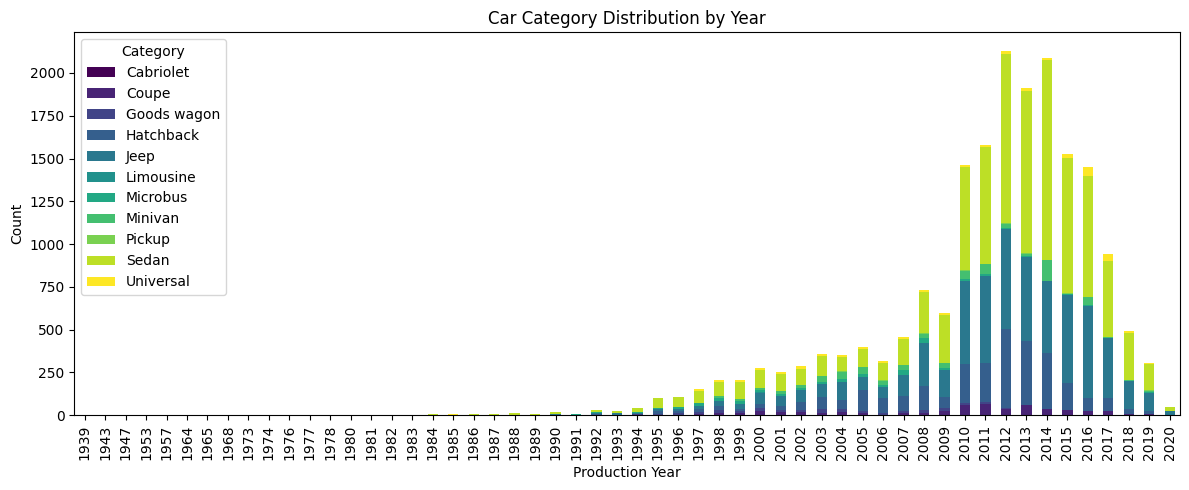

In [33]:
# stacked bar plot (for example, comparing 'Car Category' over 'Prod_year')
category_by_year = data.groupby(['Prod. year', 'Category']).size().unstack(fill_value=0)

# Plot a stacked bar chart
category_by_year.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='viridis')

# Set labels and title
plt.title('Car Category Distribution by Year')
plt.ylabel('Count')
plt.xlabel('Production Year')
plt.tight_layout()

plt.show()